1. Escoge un conjunto de datos de tu interés (https://www.kaggle.com/datasets)
2. Utilizando Pandas, realiza:
• Exploración de datos nulos, datos duplicados, cantidad de filas y
columnas.
• Limpieza de datos (Pandas: dropna, fillna, replace, etc.)
• Filtrado y selección de datos relevantes para tu análisis
• Transformación de columnas, creación de variables nuevas
• Agrupaciones y resúmenes (groupby)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ruta="/content/Amazon Echo 2 Reviews.csv.zip"
df = pd.read_csv(ruta, compression='zip')
df.head(5)

,Pageurl,Title,Review Text,Review Color,User Verified,Review Date,Review Useful Count,Configuration Text,Rating,Declaration Text
0,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Three Stars,Not great speakers,Black,Verified Purchase,10/3/2017,NaN,Echo Dot,3,NaN
1,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Four Stars,Great little gagit,White,Verified Purchase,9/26/2017,NaN,Echo Dot,4,NaN
2,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Awesome!,Awesome 👏🏽,White,Verified Purchase,9/8/2017,NaN,Echo Dot,5,NaN
3,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Five Stars,Love my Echo,Black,Verified Purchase,10/19/2017,NaN,Echo Dot,5,NaN
4,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Five Stars,Great device,Black,Verified Purchase,9/17/2017,NaN,Echo Dot,5,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6855 entries, 0 to 6854
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Pageurl              6855 non-null   object 
 1   Title                6855 non-null   object 
 2   Review Text          6850 non-null   object 
 3   Review Color         6855 non-null   object 
 4   User Verified        6641 non-null   object 
 5   Review Date          6855 non-null   object 
 6   Review Useful Count  28 non-null     float64
 7   Configuration Text   6855 non-null   object 
 8   Rating               6855 non-null   int64  
 9   Declaration Text     6 non-null      object 
dtypes: float64(1), int64(1), object(8)
memory usage: 535.7+ KB


In [7]:
df.describe(include="all")

,Pageurl,Title,Review Text,Review Color,User Verified,Review Date,Review Useful Count,Configuration Text,Rating,Declaration Text
count,6855,6855,6850,6855,6641,6855,28.000000,6855,6855.000000,6
unique,3662,3411,5832,2,1,56,NaN,2,NaN,4
top,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Five Stars,Love it,Black,Verified Purchase,9/27/2017,NaN,Echo Dot,NaN,TOP 500 REVIEWER
freq,7,1867,79,5410,6641,431,NaN,6854,NaN,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,17.071429,NaN,4.207002,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,58.266265,NaN,1.272551,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,4.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,5.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,5.000000,NaN


In [8]:
print('Valores nulos por columna:')
display(df.isnull().sum())

print('\nTotal de valores nulos en el DataFrame:')
print(df.isnull().sum().sum())

Valores nulos por columna:


,0
Pageurl,0
Title,0
Review Text,5
Review Color,0
User Verified,214
Review Date,0
Review Useful Count,6827
Configuration Text,0
Rating,0
Declaration Text,6849



Total de valores nulos en el DataFrame:
13895


In [29]:
print(df.shape)

(6855, 10)


In [30]:
df.duplicated().sum()
print(df.duplicated().sum())

0


In [31]:
df_limpio=df.copy()

In [32]:
df_limpio['Review Text'] = df_limpio['Review Text'].fillna('Desconocida')
df_limpio['User Verified'] = df_limpio['User Verified'].fillna('Desconocida')

In [33]:
print('Valores nulos por columna:')
display(df_limpio.isnull().sum())

print('\nTotal de valores nulos en el DataFrame:')
print(df_limpio.isnull().sum().sum())

Valores nulos por columna:


,0
Pageurl,0
Title,0
Review Text,0
Review Color,0
User Verified,0
Review Date,0
Review Useful Count,6827
Configuration Text,0
Rating,0
Declaration Text,6849



Total de valores nulos en el DataFrame:
13676


In [34]:
columns_to_drop = ['Pageurl', 'Review Useful Count', 'Declaration Text']
df_limpio = df_limpio.drop(columns=columns_to_drop, errors='ignore')

print("DataFrame después de eliminar columnas innecesarias:")
display(df_limpio.head())
print("\nInformación del DataFrame después de eliminar columnas:")
df_limpio.info()

DataFrame después de eliminar columnas innecesarias:


,Title,Review Text,Review Color,User Verified,Review Date,Configuration Text,Rating
0,Three Stars,Not great speakers,Black,Verified Purchase,10/3/2017,Echo Dot,3
1,Four Stars,Great little gagit,White,Verified Purchase,9/26/2017,Echo Dot,4
2,Awesome!,Awesome 👏🏽,White,Verified Purchase,9/8/2017,Echo Dot,5
3,Five Stars,Love my Echo,Black,Verified Purchase,10/19/2017,Echo Dot,5
4,Five Stars,Great device,Black,Verified Purchase,9/17/2017,Echo Dot,5



Información del DataFrame después de eliminar columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6855 entries, 0 to 6854
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Title               6855 non-null   object
 1   Review Text         6855 non-null   object
 2   Review Color        6855 non-null   object
 3   User Verified       6855 non-null   object
 4   Review Date         6855 non-null   object
 5   Configuration Text  6855 non-null   object
 6   Rating              6855 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 375.0+ KB


In [35]:
# 1. Convertir 'Review Date' a tipo datetime
df_limpio['Review Date'] = pd.to_datetime(df_limpio['Review Date'], format='%m/%d/%Y', errors='coerce')

print("Tipo de dato de 'Review Date' después de la conversión:")
print(df_limpio['Review Date'].dtype)

Tipo de dato de 'Review Date' después de la conversión:
datetime64[ns]


In [36]:
# 2. Crear nueva variable: 'Review Length' (Longitud del texto de la reseña)
df_limpio['Review Length'] = df_limpio['Review Text'].apply(len)

print("Primeras 5 filas con la nueva columna 'Review Length':")
display(df_limpio[['Review Text', 'Review Length']].head())

Primeras 5 filas con la nueva columna 'Review Length':


,Review Text,Review Length
0,Not great speakers,18
1,Great little gagit,18
2,Awesome 👏🏽,10
3,Love my Echo,12
4,Great device,12


In [37]:
# 3. Crear nueva variable: 'Day of Week' (Día de la semana de la reseña)
df_limpio['Day of Week'] = df_limpio['Review Date'].dt.day_name()

print("Conteo de reseñas por 'Day of Week':")
display(df_limpio['Day of Week'].value_counts())

Conteo de reseñas por 'Day of Week':


,count
Day of Week,
Tuesday,1536
Wednesday,1025
Friday,1011
Thursday,913
Monday,896
Sunday,874
Saturday,600


In [38]:
# 1. Calificación Promedio por Configuración del Producto
rating_by_config = df_limpio.groupby('Configuration Text')['Rating'].mean().sort_values(ascending=False)
print("Calificación Promedio por Configuración del Producto:")
display(rating_by_config)

Calificación Promedio por Configuración del Producto:


,Rating
Configuration Text,
Echo Dot + Vaux Speaker,5.000000
Echo Dot,4.206886


In [39]:
# 2. Conteo de Reseñas por Día de la Semana
reviews_by_day = df_limpio['Day of Week'].value_counts()
print("Conteo de Reseñas por Día de la Semana:")
display(reviews_by_day)

Conteo de Reseñas por Día de la Semana:


,count
Day of Week,
Tuesday,1536
Wednesday,1025
Friday,1011
Thursday,913
Monday,896
Sunday,874
Saturday,600


In [40]:
# 3. Los 5 Títulos de Reseñas Más Frecuentes
top_titles = df_limpio['Title'].value_counts().head(5)
print("Top 5 Títulos de Reseñas Más Frecuentes:")
display(top_titles)

Top 5 Títulos de Reseñas Más Frecuentes:


,count
Title,
Five Stars,1867
Four Stars,338
Three Stars,177
One Star,173
Two Stars,83


In [41]:
# 4. Longitud Promedio de la Reseña por Calificación
avg_review_length_by_rating = df_limpio.groupby('Rating')['Review Length'].mean()
print("Longitud Promedio de la Reseña por Calificación:")
display(avg_review_length_by_rating)

Longitud Promedio de la Reseña por Calificación:


,Review Length
Rating,
1,210.587814
2,220.905172
3,202.526050
4,165.942268
5,114.818887


#Preguntas y gráficas

In [ ]:
#

## Preguntas de Análisis y Visualizaciones

### Pregunta 1: ¿Cuál es la distribución general de las calificaciones (`Rating`) de los productos?

/tmp/ipykernel_4374/3523035019.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df_limpio, palette='viridis')


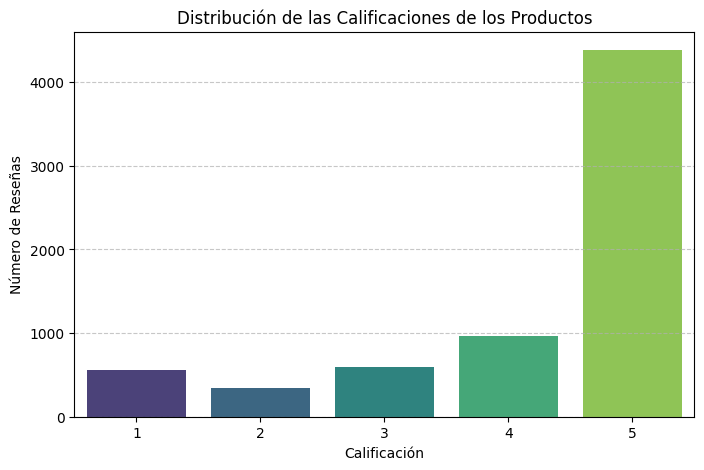

In [42]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Rating', data=df_limpio, palette='viridis')
plt.title('Distribución de las Calificaciones de los Productos')
plt.xlabel('Calificación')
plt.ylabel('Número de Reseñas')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretación de la Pregunta 1:

Este gráfico de barras muestra la frecuencia de cada calificación. Podemos observar que la mayoría de los productos reciben 5 estrellas, seguido por 4 estrellas, lo que sugiere una alta satisfacción general de los clientes. Las calificaciones bajas (1 y 2 estrellas) son significativamente menores.

### Pregunta 2: ¿Existe alguna diferencia significativa en la calificación promedio (`Rating`) entre los diferentes colores de los productos (`Review Color`)?

/tmp/ipykernel_4374/3022081220.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_by_color.index, y=avg_rating_by_color.values, palette='coolwarm')


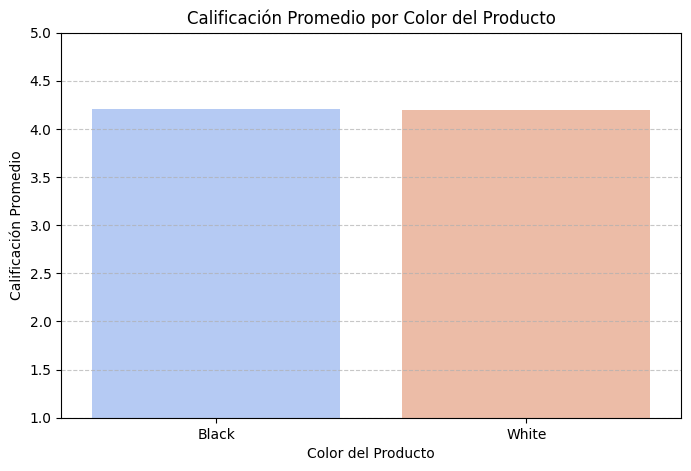

In [43]:
avg_rating_by_color = df_limpio.groupby('Review Color')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_rating_by_color.index, y=avg_rating_by_color.values, palette='coolwarm')
plt.title('Calificación Promedio por Color del Producto')
plt.xlabel('Color del Producto')
plt.ylabel('Calificación Promedio')
plt.ylim(df_limpio['Rating'].min(), df_limpio['Rating'].max()) # Ajustar límites para mejor visualización
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretación de la Pregunta 2:

Este gráfico compara la calificación promedio entre los diferentes colores de los productos. Se observa que ambos colores (Black y White) tienen calificaciones promedio muy similares, lo que sugiere que el color del producto no es un factor significativo que influya en la satisfacción general del cliente para este conjunto de datos.

### Pregunta 3: ¿Cómo se compara la longitud promedio de las reseñas (`Review Length`) entre los diferentes niveles de calificación (`Rating`)?

/tmp/ipykernel_4374/852887235.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_review_length_by_rating.index, y=avg_review_length_by_rating.values, palette='magma')


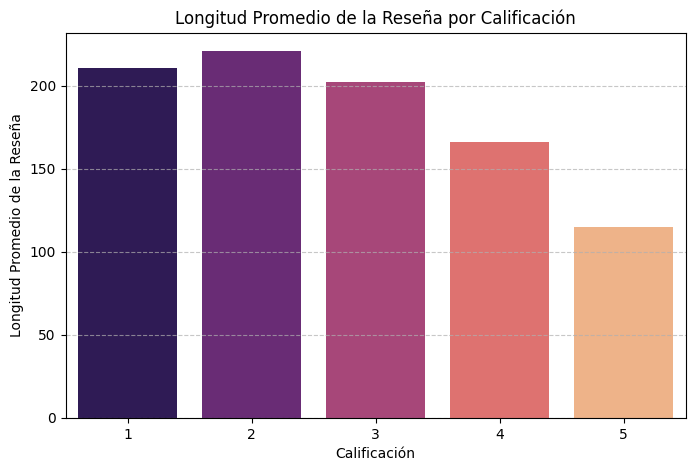

In [44]:
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_review_length_by_rating.index, y=avg_review_length_by_rating.values, palette='magma')
plt.title('Longitud Promedio de la Reseña por Calificación')
plt.xlabel('Calificación')
plt.ylabel('Longitud Promedio de la Reseña')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretación de la Pregunta 3:

La gráfica muestra una clara tendencia: las reseñas con calificaciones muy bajas (1 o 2 estrellas) tienden a ser más largas, indicando que los usuarios insatisfechos suelen detallar más sus experiencias negativas. Por otro lado, las reseñas de 4 y 5 estrellas son notablemente más cortas, sugiriendo que la satisfacción se expresa a menudo de forma más concisa.

### Pregunta 4: ¿Cuáles son los títulos de reseñas (`Title`) más utilizados por los usuarios y qué pueden indicar sobre el sentimiento general de las reseñas?

/tmp/ipykernel_4374/3217910445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.index, y=top_titles.values, palette='cividis')


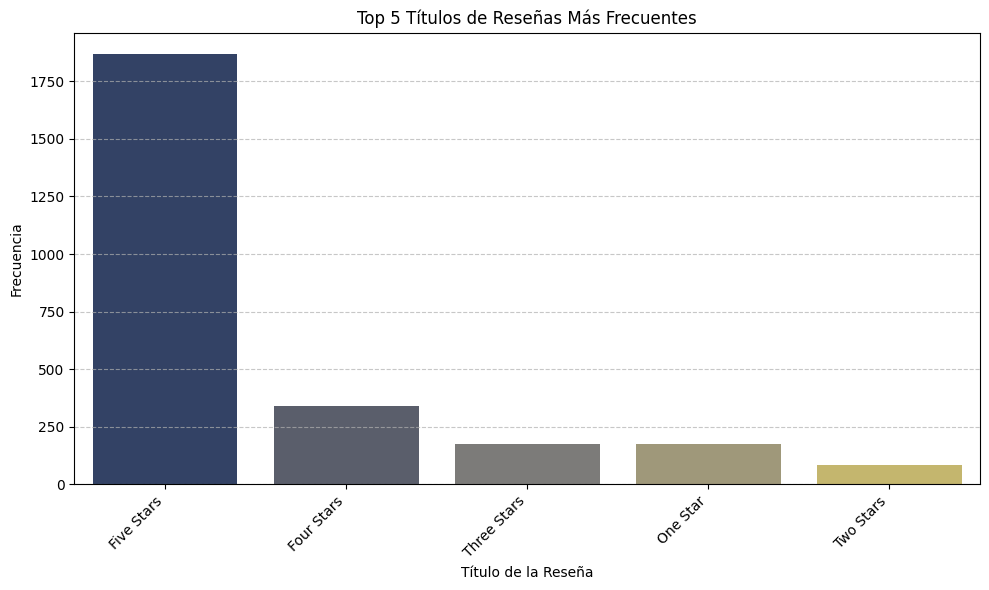

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_titles.index, y=top_titles.values, palette='cividis')
plt.title('Top 5 Títulos de Reseñas Más Frecuentes')
plt.xlabel('Título de la Reseña')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretación de la Pregunta 4:

Los títulos más frecuentes, como 'Five Stars', 'Four Stars' y 'Three Stars', son directamente indicativos de la calificación numérica, lo que sugiere que muchos usuarios simplemente usan estos títulos para reflejar su puntuación. La alta frecuencia de 'Five Stars' confirma la tendencia de calificaciones positivas. 'One Star' también aparece en el top, lo que indica que, aunque menos frecuentes, las experiencias negativas también se titulan directamente.

### Pregunta 5: ¿En qué día de la semana (`Day of Week`) se publican la mayor cantidad de reseñas y cómo se distribuye la actividad de reseñas a lo largo de la semana?

/tmp/ipykernel_4374/3196014914.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reviews_by_day_ordered.index, y=reviews_by_day_ordered.values, palette='plasma')


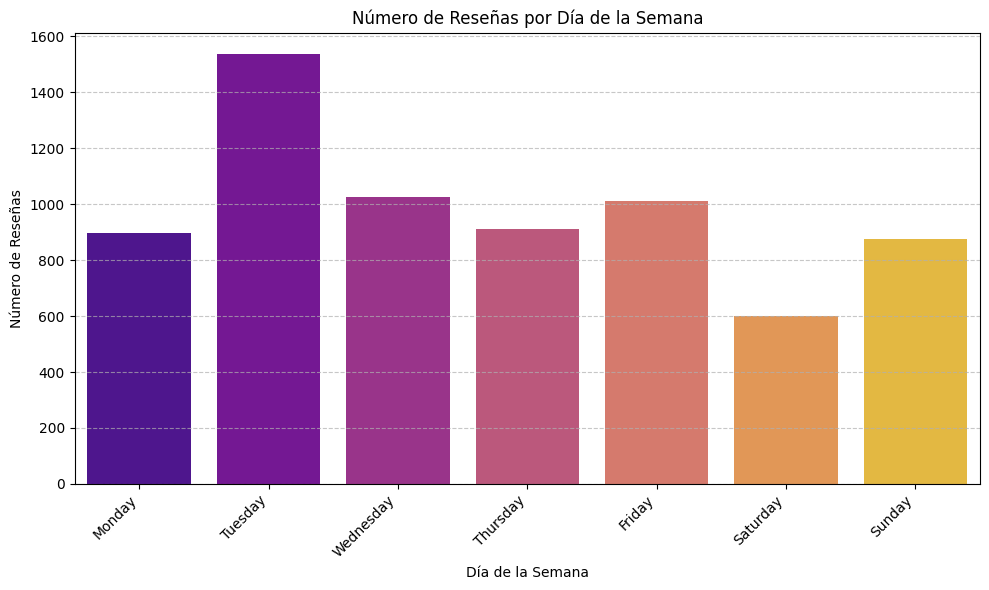

In [46]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
reviews_by_day_ordered = reviews_by_day.reindex(day_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=reviews_by_day_ordered.index, y=reviews_by_day_ordered.values, palette='plasma')
plt.title('Número de Reseñas por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Número de Reseñas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretación de la Pregunta 5:

Este gráfico muestra que los martes son el día con mayor actividad de reseñas, seguido por los miércoles y viernes. La actividad disminuye significativamente durante el fin de semana, siendo el sábado el día con menos reseñas. Esto podría sugerir que los usuarios son más propensos a dejar reseñas durante la semana laboral, quizás cuando están más activos en línea o interactuando con sus dispositivos.